# Layer 3: memory feasibility and the three-way RQ2 split (StatsBomb 360)

This notebook reruns the RQ2 forward-bias rate across three groups of teammates, not just the visible ones:

- **visible:** inside the 120 degree cone;
- **memory-feasible:** outside the cone, but a position-prediction model still places the teammate close to their true location;
- **memory-infeasible:** outside the cone, and the prediction is too unreliable to count as known.

**Two versions.**

- **Sections 1 to 4: a proxy.** These were built before the RQ3 LSTM was trained, and use linear extrapolation as an explicit stand-in. It is the same baseline the proposal says the LSTM must beat (Section 4.6).
- **Section 5: the result.** It replaces the proxy with the cross-fitted LSTM from `05_layer3_lstm_training.ipynb`. This is the result used for RQ2 and RQ3.

All VAEP-based results use the corrected candidate values (see the coordinate fix in `01_layer1_visual_constraint.ipynb`), in which every candidate has a real pass value to be compared with. `candidates_full` is loaded from the pickle saved at the end of `02_layer2_bias_analysis.ipynb`, rather than rebuilding the offside, xP and maximal-VAEP classification.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from mplsoccer import Pitch

from statsbombpy import sb
import sys
sys.path.append('..')
from src.vision_cone import add_orientation_vectors

pd.set_option('display.max_columns', None)

In [2]:
import time

CACHE_DIR = Path("../data/statsbomb_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cached_events(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"events_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            events = sb.events(match_id=match_id)
            events.to_pickle(cache_file)
            return events
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"events fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

def cached_frames(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"frames_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            frames = sb.frames(match_id=match_id, fmt='dataframe')
            frames.to_pickle(cache_file)
            return frames
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"frames fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

## 1. The classified candidate table

`candidates_full` already has visibility, offside, xP, and maximal-VAEP status computed by Layer 2. This notebook only adds the memory-feasibility dimension on top.

In [3]:
candidates_full = pd.read_pickle('../data/results/candidates_full.pkl')
print(f"{len(candidates_full)} candidate rows loaded")
print(candidates_full.columns.tolist())

with open('../data/results/xp_model_full.pkl', 'rb') as f:
    xp_model_full = pickle.load(f)

import socceraction.xthreat as xthreat
xT_model = xthreat.load_model("https://karun.in/blog/data/open_xt_12x8_v1.json")

664518 candidate rows loaded
['match_id', 'original_event_id', 'passer_location', 'candidate_location', 'visible', 'candidate_value', 'real_end_x', 'real_end_y', 'mirrored', 'candidate_value_old', 'real_value', 'cand_x', 'cand_y', 'offside', 'attacking_toward_x', 'xp_value', 'xt_origin_old', 'xt_target_old', 'xt_origin', 'xt_target', 'forward_progressive', 'legitimate_forward_progressive']


## 2. Which player is each candidate?

Linear extrapolation needs a specific player's last couple of touches before the pass, not just "some nearby teammate." 

Two things to check:
1. Does `candidates_full` (or the underlying `candidates_all3` / vision-cone table) carry a player id or name for each candidate row?
2. Does the StatsBomb 360 freeze frame itself carry a persistent player identifier for non-actor players, or only location + `teammate` + `keeper` flags?

If neither carries identity, the fallback is to match candidates to players via the main `events` dataframe: find events by teammates of the passer's team, in the same match and period, whose location at their most recent touch is closest to this candidate's freeze-frame location : an approximate match, not an exact one, and worth flagging as a limitation if used.

In [4]:
print("candidates_full columns:", candidates_full.columns.tolist())
print()

sample_match_id = candidates_full['match_id'].iloc[0]
sample_frames = cached_frames(str(sample_match_id))
print("360 frame columns:", sample_frames.columns.tolist())
print()
print(sample_frames.head(3))
print()

sample_events = cached_events(str(sample_match_id))
print("events columns (identity-relevant):", [c for c in sample_events.columns if 'player' in c.lower() or 'id' in c.lower()])

candidates_full columns: ['match_id', 'original_event_id', 'passer_location', 'candidate_location', 'visible', 'candidate_value', 'real_end_x', 'real_end_y', 'mirrored', 'candidate_value_old', 'real_value', 'cand_x', 'cand_y', 'offside', 'attacking_toward_x', 'xp_value', 'xt_origin_old', 'xt_target_old', 'xt_origin', 'xt_target', 'forward_progressive', 'legitimate_forward_progressive']

360 frame columns: ['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']

                                     id  \
0  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   
1  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   
2  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   

                                        visible_area match_id  teammate  \
0  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   
1  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   
2  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   

   actor  keeper                      

**What this shows: neither the candidate table nor the freeze frame identifies the player.**

- **`candidates_full`:** its columns are `match_id`, `original_event_id`, `passer_location`, `candidate_location`, `visible`, `candidate_value`, `real_end_x`, `real_end_y`, `mirrored`, `candidate_value_old`, `real_value`, `cand_x`, `cand_y`, `offside`, `attacking_toward_x`, `xp_value`, `xt_origin_old`, `xt_target_old`, `xt_origin`, `xt_target`, `forward_progressive` and `legitimate_forward_progressive`. There is no player id or name.
- **The 360 frame:** its columns are `id`, `visible_area`, `match_id`, `teammate`, `actor`, `keeper` and `location`. There is no persistent identity for non-actor players, by design of the freeze-frame format.
- **`events`:** these do carry identity (`player`, `player_id`, `team_id`).

So which player a candidate row is has to be inferred, by matching each candidate's freeze-frame location to the teammate whose own most recent recorded touch (from `events`) sits closest to it. This is an approximation. Unlike the offside and xP corrections, which fixed genuine bugs, it is a limit of what StatsBomb 360 data can support without player tracking.

### Position histories and identity by nearest last-known position

Two pieces:

1. `build_player_position_history` reads every event in the match with a recorded `location`, keyed by `player_id`, sorted by time. This is what both the identity match and the extrapolation read from.
2. `match_candidate_to_player` resolves identity: among teammates of the passer (same `team_id`) with a known position before this pass, pick whichever one's last known position is closest to the candidate's freeze-frame location. Ties/collisions are resolved by nearest distance, with already-matched players excluded within the same event so two candidates in the same frame don't collapse onto the same identity.

In [5]:
def build_player_position_history(m_events):
    """
    Returns {player_id: [(timestamp_seconds, (x, y), team_id), ...]}, sorted by
    time, for every event in this match where the acting player's own location
    is recorded (passes, carries, dribbles, pressures, etc.).
    """
    history = {}
    events_with_loc = m_events[m_events['location'].notna() & m_events['player_id'].notna()].copy()
    events_with_loc['timestamp_seconds'] = (
        events_with_loc['minute'] * 60 + events_with_loc['second']
    )
    events_with_loc = events_with_loc.sort_values('timestamp_seconds')

    for _, row in events_with_loc.iterrows():
        pid = row['player_id']
        history.setdefault(pid, []).append(
            (row['timestamp_seconds'], tuple(row['location']), row['team_id'])
        )
    return history


def last_known_position(history, player_id, t_target):
    """Most recent (x, y) for player_id strictly before t_target, or None."""
    if player_id not in history:
        return None
    prior = [p for p in history[player_id] if p[0] < t_target]
    return prior[-1][1] if prior else None


def recent_positions_before(history, player_id, t_target, n=2):
    """Last n (timestamp, (x, y)) pairs for player_id strictly before t_target."""
    if player_id not in history:
        return []
    prior = [(t, pos) for (t, pos, _team) in history[player_id] if t < t_target]
    return prior[-n:]


def match_candidate_to_player(history, team_id, t_target, cand_xy, exclude_ids=None):
    """
    Approximate identity resolution: among all players on `team_id` with a
    known position before t_target, return the player_id whose last known
    position is closest to the candidate's freeze-frame location, plus the
    match distance (useful for sanity-checking how confident the match is).
    """
    exclude_ids = exclude_ids or set()
    best_pid, best_dist = None, np.inf
    for pid, entries in history.items():
        if pid in exclude_ids:
            continue
        if entries[0][2] != team_id:
            continue
        pos = last_known_position(history, pid, t_target)
        if pos is None:
            continue
        dist = np.hypot(pos[0] - cand_xy[0], pos[1] - cand_xy[1])
        if dist < best_dist:
            best_dist = dist
            best_pid = pid
    return best_pid, best_dist

### Linear extrapolation and the memory-feasibility threshold

Constant-velocity extrapolation from the matched player's last two recorded touches. tau is the distance threshold below which the estimate counts as "memory-feasible", set to 4.0m, the midpoint of the proposal's 3 to 5 m defensive-line-width justification (Section 4.6). 

In [6]:
TAU = 4.0  # metres, the midpoint of the proposal's 3-5m defensive-line-width justification


def linear_extrapolation_position(recent, t_target):
    """
    recent: [(timestamp, (x, y)), ...], sorted ascending, up to 2 points.
    Returns predicted (x, y) at t_target via constant-velocity extrapolation,
    or the last known position if fewer than 2 points are available.
    """
    if len(recent) == 0:
        return None
    if len(recent) == 1:
        return recent[-1][1]

    (t0, (x0, y0)), (t1, (x1, y1)) = recent[-2], recent[-1]
    dt = t1 - t0
    if dt <= 0:
        return (x1, y1)

    vx, vy = (x1 - x0) / dt, (y1 - y0) / dt
    dt_forward = t_target - t1
    return (x1 + vx * dt_forward, y1 + vy * dt_forward)


def is_memory_feasible(predicted_pos, true_pos, tau=TAU):
    if predicted_pos is None:
        return False
    err = np.hypot(predicted_pos[0] - true_pos[0], predicted_pos[1] - true_pos[1])
    return err < tau

### Checking one example

In [7]:
sample_row = candidates_full[~candidates_full['visible']].iloc[0]
sample_match_id = str(sample_row['match_id'])

m_events_sample = cached_events(sample_match_id)
history_sample = build_player_position_history(m_events_sample)

m_events_indexed_sample = m_events_sample.set_index('id')
event_row = m_events_indexed_sample.loc[sample_row['original_event_id']]
t_target_sample = event_row['minute'] * 60 + event_row['second']
passer_team_id = event_row['team_id']

matched_pid, match_dist = match_candidate_to_player(
    history_sample, passer_team_id, t_target_sample,
    (sample_row['cand_x'], sample_row['cand_y']),
    exclude_ids={event_row['player_id']}
)
print(f"Matched player_id={matched_pid}, identity-match distance={match_dist:.2f}m")

recent_sample = recent_positions_before(history_sample, matched_pid, t_target_sample)
print(f"Recent touches before this pass: {recent_sample}")

predicted = linear_extrapolation_position(recent_sample, t_target_sample)
true_pos = (sample_row['cand_x'], sample_row['cand_y'])
if predicted is not None:
    error = np.hypot(predicted[0] - true_pos[0], predicted[1] - true_pos[1])
    print(f"predicted={predicted}, true={true_pos}, extrapolation error={error:.2f}m, memory_feasible={error < TAU}")
else:
    print("No prior touches found for this player before this event, so it can't be extrapolated.")

Matched player_id=11086.0, identity-match distance=35.21m
Recent touches before this pass: [(0, (60.0, 40.0))]
predicted=(60.0, 40.0), true=(26.9336, 52.1045), extrapolation error=35.21m, memory_feasible=False


Two distances matter here and are easy to conflate: the **identity-match distance** (how far the matched player's *last known* position was from the candidate's freeze-frame location (this is the approximation cost from not having real tracking) and the **extrapolation error** (how far the *predicted* position, projected forward in time, ends up from the true location) this is what actually feeds the memory-feasibility threshold). A small identity-match distance but large extrapolation error means the identity guess was probably right but the player moved fast between their last touch and this pass.

**What this shows**

This example is a weak one to showcase, but it is useful for two reasons.

First, it shows the passer bug that was fixed in this version. Before the fix, this same candidate was matched to player 8963, whose last recorded touch was 2 seconds into the match. That was most likely the passer, whose own touch just before the pass sat close to the candidate. With the passer now excluded, the candidate is matched to player 11086 instead, at an identity-match distance of 35.21m.

Second, it shows a cold-start problem. This pass happens in the opening seconds of the match, so almost none of the passer's teammates have a recorded touch yet. The only teammate with any history is the one who took the kick-off, whose single touch is at the centre spot (60, 40) at 0 seconds. With only one touch there is no velocity to estimate, so the prediction is just that last known position, and the extrapolation error (35.21m) is identical to the identity-match distance. The model is not predicting movement here at all.

So early in a match, and more generally for any player who has not touched the ball for a while, the proxy has little or nothing to work with. A later-match example with a longer touch history would give a fairer picture of how the extrapolation performs when real velocity information exists.

## 3. Memory feasibility for every invisible candidate (proxy)

Runs identity matching and extrapolation across every row in `candidates_full` where `visible` is False, grouped by match and event so each match's history is only built once and matched candidates within the same event don't collide onto the same player.

In [8]:
def classify_memory_feasibility_for_match(match_candidates, mid):
    m_events = cached_events(str(mid))
    history = build_player_position_history(m_events)
    m_events_indexed = m_events.set_index('id')

    results = []
    for event_id, event_candidates in match_candidates.groupby('original_event_id'):
        if event_id not in m_events_indexed.index:
            for idx in event_candidates.index:
                results.append((idx, None, np.nan, False))
            continue

        event_row = m_events_indexed.loc[event_id]
        t_target = event_row['minute'] * 60 + event_row['second']
        team_id = event_row['team_id']

        matched_this_event = {event_row['player_id']}  # never match a candidate to the passer
        for idx, cand in event_candidates.iterrows():
            cand_xy = (cand['cand_x'], cand['cand_y'])
            matched_pid, match_dist = match_candidate_to_player(
                history, team_id, t_target, cand_xy, exclude_ids=matched_this_event
            )
            if matched_pid is None:
                results.append((idx, None, np.nan, False))
                continue
            matched_this_event.add(matched_pid)

            recent = recent_positions_before(history, matched_pid, t_target)
            predicted = linear_extrapolation_position(recent, t_target)
            feasible = is_memory_feasible(predicted, cand_xy)
            results.append((idx, matched_pid, match_dist, feasible))

    return results


invisible = candidates_full[~candidates_full['visible']].copy()
all_results = []

unique_match_ids = invisible['match_id'].unique()
for i, mid in enumerate(unique_match_ids):
    match_candidates = invisible[invisible['match_id'] == mid]
    all_results.extend(classify_memory_feasibility_for_match(match_candidates, mid))
    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{len(unique_match_ids)}] matches processed")

results_df = pd.DataFrame(all_results, columns=['idx', 'matched_player_id', 'identity_match_dist', 'memory_feasible']).set_index('idx')
invisible = invisible.join(results_df)

print(invisible['memory_feasible'].value_counts(dropna=False))
print(f"Median identity-match distance: {invisible['identity_match_dist'].median():.2f}m")

[20/166] matches processed
[40/166] matches processed
[60/166] matches processed
[80/166] matches processed
[100/166] matches processed
[120/166] matches processed
[140/166] matches processed
[160/166] matches processed
memory_feasible
False    421089
True      19976
Name: count, dtype: int64
Median identity-match distance: 15.04m


Check the identity-match distance distribution before trusting the memory-feasible counts. If it's mostly large (players scattered far from any teammate's last known position), the identity resolution itself is unreliable and the memory-feasible rate below should be reported with that caveat attached, not as a clean number.

saved ..\data\results\figures\rq3_identity_match_distance.png


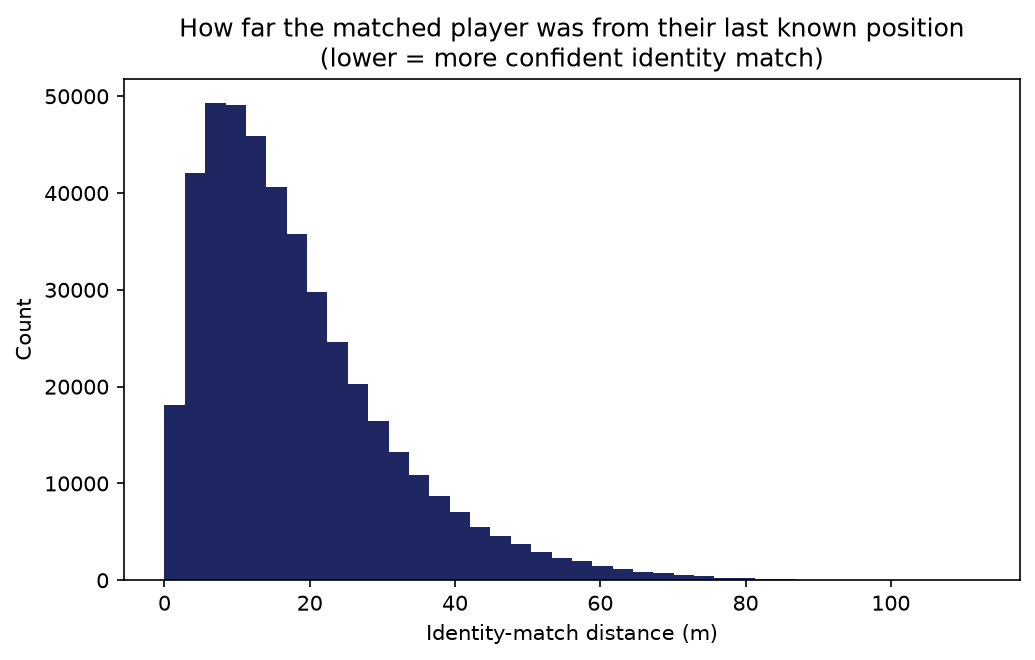

count    439126.000000
mean         18.212645
std          13.273009
min           0.003667
25%           8.432031
50%          15.038538
75%          24.507064
max         112.173550
Name: identity_match_dist, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.hist(invisible['identity_match_dist'].dropna(), bins=40)
ax.set_xlabel('Identity-match distance (m)')
ax.set_ylabel('Count')
ax.set_title('How far the matched player was from their last known position\n(lower = more confident identity match)')
plt.tight_layout()
save_fig(fig, 'rq3_identity_match_distance.png')
plt.show()

print(invisible['identity_match_dist'].describe())

**What this shows**

The median identity-match distance across all invisible candidates is 15.04m, well above the 4.0m threshold used to call something memory-feasible. So for the typical invisible candidate, the nearest-teammate guess used to establish identity is not confident on its own, before extrapolation error is even added on top.

The median rose from 12.94m before the passer fix to 15.04m after it. That is expected: candidates standing near the passer were previously being matched to the passer at a very short distance, which made identity matching look more confident than it really was.

The candidates that do end up classified as memory-feasible sit in the low tail of this distribution, a real but small group, not the norm. This is the numeric basis for treating the memory_feasible label as approximate rather than a confirmed identity match.

**Units in the proxy section.** The distances in this proxy section (the identity-match distances, the 4.0 threshold and the histogram) are in StatsBomb units, which are yards, even though they are labelled m. This only affects the superseded proxy. The LSTM section below converts errors to metres properly.

## 4. The forward-bias rate in three groups (proxy)

Uses the same filters as Layer 2 (onside, xP of at least 0.05, maximal-VAEP by xT and VAEP), but without Layer 2's visibility requirement. Layer 2's `legitimate_forward_progressive` column only counts visible candidates, so it is automatically False for every invisible candidate and would make both invisible groups read 0 percent. The new `legitimate_forward_progressive_any_vis` column applies the other three filters only, since visibility is now the group label rather than a filter.

In [10]:
candidates_full['group'] = 'visible'
candidates_full.loc[invisible.index, 'group'] = invisible['memory_feasible'].map(
    {True: 'memory_feasible', False: 'memory_infeasible'}
)
candidates_full.loc[candidates_full['visible'], 'group'] = 'visible'

print(candidates_full['group'].value_counts())

group
memory_infeasible    421089
visible              223453
memory_feasible       19976
Name: count, dtype: int64


**What this shows**

19976 of the 441065 invisible candidate rows, about 4.5 percent, cleared the 4.0m memory-feasibility threshold. The remaining 95.5 percent fall into memory_infeasible.

Before the passer fix, memory_feasible held 23822 rows, so 3846 rows (about 16 percent of the old group) only qualified because they had been matched to the passer. Those rows have now moved into memory_infeasible.

The imbalance matters for how much weight to put on the memory_feasible rate below. It is a small, unusual subset of invisible candidates, not a representative sample of them, so any pattern found in it describes that subset specifically rather than invisible candidates in general.

In [11]:
candidates_full['legitimate_forward_progressive_any_vis'] = (
    (~candidates_full['offside'].fillna(True))
    & (candidates_full['xp_value'] >= 0.05)
    & candidates_full['forward_progressive']
)

from scipy.stats import binomtest

for group_name, group_df in candidates_full.groupby('group'):
    pass_level_group = group_df.groupby(['match_id', 'original_event_id']).agg(
        had_legit_forward_option=('legitimate_forward_progressive_any_vis', 'any')
    ).reset_index()
    n_total = len(pass_level_group)
    n_bypassed = int(pass_level_group['had_legit_forward_option'].sum())
    rate = n_bypassed / n_total if n_total else float('nan')
    result = binomtest(n_bypassed, n_total, p=0.5) if n_total else None
    p_str = f"{result.pvalue:.4f}" if result else "n/a"
    print(f"{group_name}: {n_bypassed}/{n_total} = {rate:.1%}  (binomial p={p_str})")

memory_feasible: 4666/18191 = 25.7%  (binomial p=0.0000)
memory_infeasible: 59777/96646 = 61.9%  (binomial p=0.0000)
visible: 38418/82045 = 46.8%  (binomial p=0.0000)


**What this shows**

At the pass level, memory_feasible sits at 25.7 percent, visible at 46.8 percent and memory_infeasible at 61.9 percent. The expectation going in was that memory_feasible would land between the other two, since more knowledge of a teammate's position should mean more visible-like behaviour. It does not: it is well below both.

Before reading these numbers as differences in decision-making, note what each rate measures. Each group's denominator is the passes that had at least one candidate in that group, because grouping happens before the pass-level aggregation. That is also why the visible group shows 46.8 percent here rather than the 38.9 percent RQ2 headline. The headline divides by all 98652 qualifying passes, while this rate divides only by the 82045 passes that had a visible candidate. Both numbers are correct; they answer different questions. One is a flat rate across all passes, the other a rate conditional on a group having an option at all.

The next two checks test why memory_feasible is so much lower: whether its candidates are positioned differently, and whether the number of candidates per pass is distorting the pass-level comparison.

**Limits of the proxy.** These figures use constant-velocity extrapolation as a stand-in for the RQ3 model, as in the proposal's own baseline comparison. Identity for invisible candidates is inferred by nearest last-known-position matching rather than read from tracking data. Section 5 replaces the extrapolation with the LSTM. The identity matching is a limit of the data source and is not used by the LSTM, which follows players through linked freeze frames instead.

In [12]:
check = candidates_full[candidates_full['group'].isin(['memory_feasible', 'memory_infeasible'])].copy()
check['xt_gain'] = check['xt_target'] - check['xt_origin']
check = check.join(invisible[['identity_match_dist']])

summary = check.groupby('group').agg(
    n_rows=('forward_progressive', 'size'),
    share_forward_progressive=('forward_progressive', 'mean'),
    mean_xt_gain=('xt_gain', 'mean'),
    median_identity_match_dist=('identity_match_dist', 'median'),
)
print(summary)

                   n_rows  share_forward_progressive  mean_xt_gain  \
group                                                                
memory_feasible     19976                   0.253404      0.000755   
memory_infeasible  421089                   0.398692      0.004370   

                   median_identity_match_dist  
group                                          
memory_feasible                      3.093823  
memory_infeasible                   15.688649  


**What this shows**

The check supports the hypothesis that the constant-velocity baseline mostly succeeds on players who are not making runs. Memory-feasible candidates are much less often maximal-VAEP than memory-infeasible ones (25.3 percent against 39.9 percent), and their mean xT gain is about six times smaller (0.0008 against 0.0044). The players the baseline predicts well tend to sit roughly level with the passer rather than ahead of the play.

The same pattern held before the passer fix and before the xT unit fix, so it is not explained by candidates next to the passer being matched to the passer, or by the xT scale. The xT gains are smaller than in earlier versions of this notebook because the corrected xT no longer inflates values near the opponent's box. The near-zero gain for memory-feasible candidates reflects where they genuinely stand.

The identity-match distance splits cleanly between the groups: a median of 3.09m for memory-feasible against 15.69m for memory-infeasible. Identity matching is fairly confident within the memory-feasible group. This is partly true by construction, since a candidate can only end up under 4.0m of extrapolation error if its identity match was usually close to begin with.

**A purely mechanical effect.** The pass-level rate asks whether a pass had at least one legitimate forward option within a group, so a pass with more candidates in that group has more chances to contain one. Memory-feasible passes have about 1.1 candidates each in their group (19976 rows over 18191 passes), against about 4.4 for memory-infeasible (421089 over 96646) and about 2.7 for visible (223453 over 82045). Part of the gap between 25.7 percent and 61.9 percent comes from this difference in group size per pass, not from anything about the players. The next cell compares the groups at the candidate level, which removes this effect.

In [13]:
per_candidate = candidates_full.groupby('group').agg(
    n_rows=('legitimate_forward_progressive_any_vis', 'size'),
    n_passes=('original_event_id', lambda s: s.groupby(candidates_full.loc[s.index, 'match_id']).nunique().sum()),
    share_legit_forward=('legitimate_forward_progressive_any_vis', 'mean'),
)
per_candidate['candidates_per_pass'] = per_candidate['n_rows'] / per_candidate['n_passes']
print(per_candidate)

                   n_rows  n_passes  share_legit_forward  candidates_per_pass
group                                                                        
memory_feasible     19976     18191             0.245495             1.098125
memory_infeasible  421089     96646             0.367704             4.357025
visible            223453     82045             0.341325             2.723542


**What this shows**

At the candidate level, where every candidate counts once regardless of how many teammates share its pass, 36.8 percent of memory-infeasible candidates are legitimate forward options, against 34.1 percent of visible and 24.5 percent of memory-feasible candidates.

This explains most of the spread in the pass-level rates. Memory-infeasible passes carry the most candidates each (4.4, against 2.7 for visible and 1.1 for memory-feasible). That gives them the most chances to contain at least one legitimate option, so their pass-level rate (61.9 percent) sits far above the others, even though their candidate-level share is only 2.6 points above visible.

The low memory-feasible share reflects which players the proxy selects, not how passers decide. The constant-velocity baseline predicts well mainly for players standing level with the passer rather than making runs: 25.3 percent maximal-VAEP and a mean xT gain of 0.0008, against 39.9 percent and 0.0044 for memory-infeasible. A player who is not ahead of the ball can rarely be a maximal-VAEP option.

All of these patterns held after the passer fix, which removed 3846 wrongly matched rows from memory_feasible, so they are not an artifact of that bug.

**Conclusion for the proxy.** this proxy split does not support a clean comparison of decision-making bias across the three perception groups. Differences between the groups are driven mainly by candidate position and by the number of candidates per pass, and the memory-feasible label itself is shaped by the baseline's preference for players who are not moving. The three-way pipeline is built and working. A fair comparison needs a position model that does not systematically select for static players, which is what the trained LSTM in the next section provides.

## 5. The three-way split with the trained LSTM

This replaces the linear-extrapolation proxy above with the trained LSTM. An invisible teammate counts as memory-feasible if they were seen within the previous two seconds (at least one earlier point in their track) and the cross-fitted LSTM places them within tau of their true position. Teammates with no earlier point cannot be predicted, so they count as memory-infeasible, along with those the LSTM places further than tau away. tau is 4 m, the midpoint of the proposal's 3 to 5 m range, now properly in metres (the proxy's 4.0 was in StatsBomb yards).

Two lessons carry over from the proxy analysis. The pass-level rate depends on how many candidates each pass has in a group, so the candidate-level share is the fairer comparison between groups. And a group can differ simply because of where its players stand, so the share of maximal-VAEP candidates and the mean xT gain are shown alongside, to separate position from decision-making.

In [14]:
TAUS = [3.0, 4.0, 5.0]   # metres; the proposal's 3 to 5 m range
TAU_MAIN = 4.0

cf = pd.read_pickle('../data/results/rq3_crossfit_predictions.pkl')
cf['match_id'] = cf['match_id'].astype(str)

cands = candidates_full.copy()
cands['match_id'] = cands['match_id'].astype(str)
cands['legitimate_forward_progressive_any_vis'] = (
    (~cands['offside'].fillna(True))
    & (cands['xp_value'] >= 0.05)
    & cands['forward_progressive']
)
cands['xt_gain'] = cands['xt_target'] - cands['xt_origin']

keys = ['match_id', 'original_event_id', 'cand_x', 'cand_y']
inv = (cands[~cands['visible']].rename_axis('row').reset_index()
       .merge(cf[keys + ['n_hist', 'horizon_s', 'err_last_m', 'err_lstm_m']].drop_duplicates(keys),
              on=keys, how='left', validate='many_to_one')
       .set_index('row'))

print(f"{len(inv)} invisible candidates, {inv['n_hist'].isna().sum()} without a cross-fitted prediction")
print(f"with at least 1 earlier point: {(inv['n_hist'] >= 1).mean():.1%}")


def group_labels(tau, err_col='err_lstm_m'):
    """visible / memory_feasible (seen recently and predicted within tau) / memory_infeasible."""
    labels = pd.Series('visible', index=cands.index, dtype=object)
    feasible = (inv['n_hist'] >= 1) & (inv[err_col] < tau)
    labels.loc[inv.index] = np.where(feasible, 'memory_feasible', 'memory_infeasible')
    return labels


def three_way_summary(labels):
    df = cands.assign(group=labels)
    out = {}
    for name, g in df.groupby('group'):
        per_pass = g.groupby(['match_id', 'original_event_id'])['legitimate_forward_progressive_any_vis'].any()
        out[name] = {
            'candidates': len(g),
            'passes': len(per_pass),
            'candidates_per_pass': len(g) / len(per_pass),
            'pass_level_rate': per_pass.mean(),
            'candidate_level_share': g['legitimate_forward_progressive_any_vis'].mean(),
            'share_forward_progressive': g['forward_progressive'].mean(),
            'mean_xt_gain': g['xt_gain'].mean(),
        }
    order = ['visible', 'memory_feasible', 'memory_infeasible']
    return pd.DataFrame(out).T.loc[[o for o in order if o in out]]

441065 invisible candidates, 0 without a cross-fitted prediction
with at least 1 earlier point: 63.6%


In [15]:
labels_main = group_labels(TAU_MAIN)
print(f"tau = {TAU_MAIN} m")
print(labels_main.value_counts())
print()
print(three_way_summary(labels_main).round(3).to_string())

cands.assign(group=labels_main)[keys + ['visible', 'group', 'legitimate_forward_progressive_any_vis']] \
    .to_pickle('../data/results/rq2_three_way_groups_lstm.pkl')

tau = 4.0 m
memory_infeasible    232800
visible              223453
memory_feasible      208265
Name: count, dtype: int64

                   candidates   passes  candidates_per_pass  pass_level_rate  candidate_level_share  share_forward_progressive  mean_xt_gain
visible              223453.0  82045.0                2.724            0.468                  0.341                      0.372         0.005
memory_feasible      208265.0  55636.0                3.743            0.585                  0.372                      0.403         0.004
memory_infeasible    232800.0  68087.0                3.419            0.551                  0.354                      0.383         0.004


**What this shows**

With the LSTM defining memory feasibility, 208265 invisible candidates (47.2 percent) are memory-feasible and 232800 are memory-infeasible, next to 223453 visible candidates. That is about ten times the size of the proxy's memory-feasible group (4.5 percent), because the LSTM follows off-ball players through freeze frames rather than relying on their ball touches.

**The three groups are close together.** At the candidate level, 34.1 percent of visible, 37.2 percent of memory-feasible and 35.4 percent of memory-infeasible candidates are legitimate maximal-VAEP options that the passer did not take, a spread of 3.0 percentage points. The small differences follow where the candidates stand: 37.2, 40.3 and 38.3 percent of them are maximal-VAEP, in the same order. Among maximal-VAEP candidates, the share that is also onside and completable is almost identical in all three groups (about 92 percent). So the groups differ only in how often their players are in a forward position, not in anything the filters or the passer's decision add.

This differs from the result before the coordinate fix, when visible candidates stood out (42.7 percent, against 31.6 percent for both invisible groups). That gap came from two problems now corrected:

- candidate values were computed in the wrong coordinates;
- invisible teammates on passes with no visible teammate had no real value to be compared with, so they could never count.

With both fixed, visible teammates are not more often missed forward options than invisible ones. The xT unit fix moved every share up by about half a point to one point and left the pattern unchanged.

The pass-level rates (46.8, 58.5 and 55.1 percent) are harder to compare, because the groups carry different numbers of candidates per pass (2.7, 3.7 and 3.4), and a pass with more candidates in a group has more chances to contain a legitimate option.

In [16]:
rows = []
for tau in TAUS:
    for rule, col in [('LSTM', 'err_lstm_m'), ('last position', 'err_last_m')]:
        s = three_way_summary(group_labels(tau, col))
        rows.append({
            'tau_m': tau, 'rule': rule,
            'feasible_candidates': int(s.loc['memory_feasible', 'candidates']),
            'feasible_share_of_invisible': s.loc['memory_feasible', 'candidates'] / len(inv),
            'share_visible': s.loc['visible', 'candidate_level_share'],
            'share_feasible': s.loc['memory_feasible', 'candidate_level_share'],
            'share_infeasible': s.loc['memory_infeasible', 'candidate_level_share'],
        })
print(pd.DataFrame(rows).round(3).to_string(index=False))

lstm_lab = group_labels(TAU_MAIN, 'err_lstm_m').loc[inv.index]
last_lab = group_labels(TAU_MAIN, 'err_last_m').loc[inv.index]
print()
print(f"at tau = {TAU_MAIN} m, LSTM and last-position rules agree on {(lstm_lab == last_lab).mean():.1%} "
      f"of invisible candidates")

 tau_m          rule  feasible_candidates  feasible_share_of_invisible  share_visible  share_feasible  share_infeasible
   3.0          LSTM               166213                        0.377          0.341           0.370             0.358
   3.0 last position               160895                        0.365          0.341           0.368             0.359
   4.0          LSTM               208265                        0.472          0.341           0.372             0.354
   4.0 last position               203246                        0.461          0.341           0.370             0.355
   5.0          LSTM               235457                        0.534          0.341           0.372             0.351
   5.0 last position               231167                        0.524          0.341           0.371             0.352

at tau = 4.0 m, LSTM and last-position rules agree on 95.7% of invisible candidates


**What this shows**

The result does not depend on the choice of tau. Across 3, 4 and 5 m, the memory-feasible group grows from 37.7 to 53.4 percent of invisible candidates. Its share of legitimate forward options stays between 37.0 and 37.2 percent, while the infeasible group's moves from 35.8 to 35.1 percent. The gap between the two is between 1.2 and 2.1 percentage points at every threshold, and both stay within about 3 points of the visible group (34.1 percent).

It also does not depend on using the LSTM. Defining feasibility with last position instead gives almost the same groups (the two rules agree on 95.7 percent of invisible candidates at 4 m) and the same shares. This is expected: the LSTM's errors differ from last position's by only about 0.1 m on average, which moves few teammates across a threshold of several metres.

In [17]:
inf_rows = inv[labels_main.loc[inv.index] == 'memory_infeasible']
reason = np.where(inf_rows['n_hist'] >= 1, 'seen recently, predicted beyond tau', 'no earlier point')
print(inf_rows.assign(reason=reason).groupby('reason').agg(
    candidates=('legitimate_forward_progressive_any_vis', 'size'),
    candidate_level_share=('legitimate_forward_progressive_any_vis', 'mean'),
    share_forward_progressive=('forward_progressive', 'mean'),
    mean_xt_gain=('xt_gain', 'mean'),
).round(3).to_string())

                                     candidates  candidate_level_share  share_forward_progressive  mean_xt_gain
reason                                                                                                         
no earlier point                         160596                  0.344                      0.373         0.004
seen recently, predicted beyond tau       72204                  0.376                      0.404         0.004


**What this shows**

The infeasible group combines two kinds of teammate:

- 160596 with no earlier point in their track, usually because they had only just come into the camera view;
- 72204 who were seen recently, but whom the LSTM places more than 4 m from their true position.

Of these, 34.4 and 37.6 percent are legitimate forward options, and 37.3 and 40.4 percent are maximal-VAEP.

This locates where the small gap between memory-feasible (37.2 percent) and memory-infeasible (35.4 percent) comes from. Teammates who were seen recently look the same whether the LSTM places them within 4 m (37.2 percent) or beyond it (37.6 percent), so prediction accuracy makes no difference. The only group that stands slightly apart is the teammates with no earlier point. They are also the least often maximal-VAEP, so the difference again follows where the players stand rather than whether their position could be remembered.

**Conclusion for the three-way split**

Splitting invisible teammates by whether their position could be recovered from short-term memory makes at most a small difference to how often they represent a missed maximal-VAEP option, and that difference follows their position on the pitch. With the corrected values, the same is true of the split between visible and invisible teammates. The share of missed forward options is similar in all three groups (34.1, 37.2 and 35.4 percent), and the differences track how often each group's players are in forward positions. As far as this data can measure it (positions recoverable within the last two seconds), neither the vision cone nor memory feasibility separates teammates who were more or less often left unused as forward options.

This split describes the pool of available options, not the choices passers made. Whether passers actually use memory is a separate question. It is tested by looking at the passes they did make to teammates outside their vision cone: if memory guides those blind passes, their receivers should be memory-feasible more often than the other invisible teammates who were available at the same moment.

### Are the differences between the groups real?

The three-way shares differ by only one or two percentage points, so this checks whether those gaps are distinguishable from zero. Candidates from the same match are not independent, so, as in the LSTM evaluation, the uncertainty comes from resampling whole matches: the 166 matches are drawn with replacement 5000 times and every group's share is recomputed each time.

Three quantities are compared across the groups. The first is the share of legitimate forward options, which is the three-way result itself. The second is the share of maximal-VAEP candidates, which reflects where the players stand. The third is the share of maximal-VAEP candidates that are also onside and completable, which removes the effect of position and shows whether anything else differs between the groups. If a gap in the first survives but vanishes in the third, it comes from position, not from perception or memory.

In [18]:
def share_bootstrap(labels, col, pairs, mask=None, n_boot=5000, seed=0):
    """Share of candidates with `col` in each group, and the difference between pairs of groups,
    with 95% intervals from resampling whole matches. mask: optional rows to keep."""
    df = cands.assign(group=labels)
    if mask is not None:
        df = df[mask]
    tab = df.groupby(['match_id', 'group'])[col].agg(['sum', 'count']).unstack('group', fill_value=0)
    groups = list(tab['sum'].columns)
    S, C = tab['sum'].to_numpy(float), tab['count'].to_numpy(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(tab), size=(n_boot, len(tab)))
    boot = S[idx].sum(axis=1) / C[idx].sum(axis=1)          # (n_boot, groups)
    point = S.sum(axis=0) / C.sum(axis=0)
    out = {}
    for a, b in pairs:
        ia, ib = groups.index(a), groups.index(b)
        d = boot[:, ia] - boot[:, ib]
        out[f'{a} - {b}'] = {'share_a': point[ia], 'share_b': point[ib],
                             'difference': point[ia] - point[ib],
                             'ci_low': np.percentile(d, 2.5), 'ci_high': np.percentile(d, 97.5)}
    return pd.DataFrame(out).T


LEGIT = 'legitimate_forward_progressive_any_vis'
three = [('memory_feasible', 'memory_infeasible'),
         ('memory_feasible', 'visible'),
         ('memory_infeasible', 'visible')]

labels = group_labels(TAU_MAIN)
invisible_vs_visible = labels.where(labels == 'visible', 'invisible')

print(f"1. Legitimate forward options, tau = {TAU_MAIN:.0f} m (difference in share, 95% CI)")
print(pd.concat([share_bootstrap(labels, LEGIT, three),
                 share_bootstrap(invisible_vs_visible, LEGIT, [('invisible', 'visible')])]).round(4).to_string())

print("\n2. Maximal-VAEP candidates (where the players stand)")
print(pd.concat([share_bootstrap(labels, 'forward_progressive', three),
                 share_bootstrap(invisible_vs_visible, 'forward_progressive', [('invisible', 'visible')])]).round(4).to_string())

print("\n3. Legitimate, among maximal-VAEP candidates only (what the filters and the passer add)")
print(pd.concat([share_bootstrap(labels, LEGIT, three, mask=cands['forward_progressive']),
                 share_bootstrap(invisible_vs_visible, LEGIT, [('invisible', 'visible')],
                                 mask=cands['forward_progressive'])]).round(4).to_string())

print("\n4. Feasible against infeasible at each tau (legitimate forward options)")
print(pd.concat({f'tau = {t:.0f} m': share_bootstrap(group_labels(t), LEGIT, [three[0]]) for t in TAUS})
      .round(4).to_string())

print("\n5. Inside the invisible group: feasible, seen but beyond tau, and no earlier point")
sub = labels.copy()
sub.loc[inv.index[(labels.loc[inv.index] == 'memory_infeasible') & (inv['n_hist'] >= 1)]] = 'seen_beyond_tau'
sub.loc[inv.index[inv['n_hist'].fillna(0) < 1]] = 'no_earlier_point'
print(share_bootstrap(sub, LEGIT, [('memory_feasible', 'seen_beyond_tau'),
                                   ('memory_feasible', 'no_earlier_point'),
                                   ('seen_beyond_tau', 'no_earlier_point')]).round(4).to_string())

1. Legitimate forward options, tau = 4 m (difference in share, 95% CI)
                                     share_a  share_b  difference  ci_low  ci_high
memory_feasible - memory_infeasible   0.3716   0.3538      0.0178  0.0134   0.0224
memory_feasible - visible             0.3716   0.3413      0.0302  0.0247   0.0359
memory_infeasible - visible           0.3538   0.3413      0.0124  0.0067   0.0180
invisible - visible                   0.3622   0.3413      0.0208  0.0157   0.0258

2. Maximal-VAEP candidates (where the players stand)
                                     share_a  share_b  difference  ci_low  ci_high
memory_feasible - memory_infeasible   0.4026   0.3827      0.0199  0.0154   0.0247
memory_feasible - visible             0.4026   0.3716      0.0310  0.0252   0.0369
memory_infeasible - visible           0.3827   0.3716      0.0111  0.0053   0.0168
invisible - visible                   0.3921   0.3716      0.0205  0.0152   0.0258

3. Legitimate, among maximal-VAEP candidates

**What this shows**

With more than 200000 candidates in each group, every gap in legitimate forward options is distinguishable from zero, but all of them are small:

- at tau = 4 m, memory-feasible candidates are legitimate forward options 1.78 percentage points more often than memory-infeasible ones (95 percent interval 1.34 to 2.24);
- invisible candidates are legitimate forward options 2.08 points more often than visible ones (1.57 to 2.58).

The second gap runs in the opposite direction to what a perception effect would predict: teammates the passer could see are, if anything, slightly less often left unused as forward options.

The maximal-VAEP shares differ by almost exactly the same amounts: 1.99 points between feasible and infeasible, 2.05 points between invisible and visible. Once only maximal-VAEP candidates are compared, the gaps almost disappear. Among them, the share that is also onside and completable is 92.3 percent for memory-feasible and 92.4 percent for memory-infeasible (difference -0.15, interval -0.49 to 0.19, which includes zero), and differs between invisible and visible by only 0.52 points. So the groups differ in how often their players stand in forward positions, and hardly at all in anything the offside and xP filters add once position is accounted for.

The split inside the invisible group shows where the memory gap comes from. Teammates seen in the previous two seconds look the same whether the LSTM places them within 4 m or beyond it: 37.2 against 37.6 percent (difference -0.48, interval -1.07 to 0.14, which includes zero). The group that stands apart is the teammates with no earlier point, who had only just come into the camera view: 34.4 percent, 2.8 to 3.3 points below both groups of teammates seen recently.

Prediction accuracy therefore plays no part. Whether a teammate had been in view recently does, and that follows where they stand relative to the ball and the camera. This also explains why the feasible against infeasible gap grows with tau (1.21, 1.78 and 2.07 points at 3, 4 and 5 m): a larger tau moves more recently seen teammates into the feasible group, leaving the infeasible group increasingly made up of teammates with no earlier point.

Conclusion: neither visibility nor memory feasibility separates teammates by how often they were missed maximal-VAEP options in any meaningful way. The small differences that exist are explained by where the players stand. With position held fixed, they are at most about half a percentage point (0.59 at most).

## 6. Figures

These cells make the summary chart in the shared colour scheme, from this notebook's own results, and save it to `../data/results/figures/`. They do not change any result.

The top panel is the pass-level rate by option pool (saved by `03_layer2_risk_and_context.ipynb`), the bottom panel the candidate-level share by perception group at tau = 4 m (saved by this notebook). Only the setup cells at the top are needed.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# shared colours and style for the figures below
NAVY, GREEN, GREY, LIGHT, TXT = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0', '#1B1B1F'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#6B7280', 'axes.labelcolor': TXT,
                     'xtick.color': TXT, 'ytick.color': '#6B7280'})


def deck_bars(ax, labels, vals, colours, lo=None, hi=None, fmt='{:.1f}%', ymax=None, off=1.0):
    """Bar chart in the shared style, with optional confidence intervals and value labels."""
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colours, width=0.62)
    if lo is not None:
        ax.errorbar(x, vals, yerr=[np.subtract(vals, lo), np.subtract(hi, vals)],
                    fmt='none', ecolor=TXT, capsize=5, lw=1.2)
    for i, v in enumerate(vals):
        top = hi[i] if hi is not None else v
        ax.text(i, top + off, fmt.format(v), ha='center', va='bottom', fontsize=13, fontweight='bold', color=TXT)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    if ymax:
        ax.set_ylim(0, ymax)


saved ..\data\results\figures\rq2_unused_options_by_perception.png


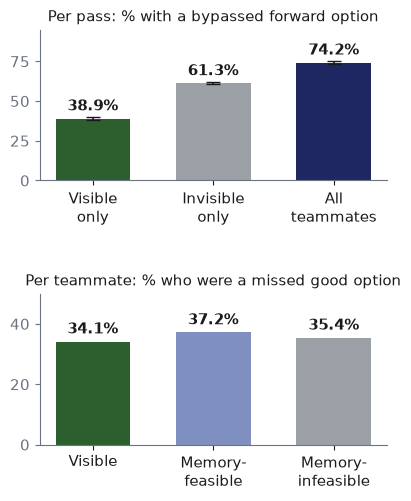

[38.9, 61.3, 74.2] {'memory_feasible': 37.2, 'memory_infeasible': 35.4, 'visible': 34.1}


In [20]:
# "Which options get left unused?" chart: per-pass rates by option pool (top) and
# per-teammate shares by perception group (bottom). Reads saved results only.
rates = pd.read_pickle('../data/results/rq2_risk_context_summary.pkl')['rates']   # saved by 03_layer2_risk_and_context.ipynb
groups = pd.read_pickle('../data/results/rq2_three_way_groups_lstm.pkl')            # saved above (tau = 4 m)
shares = 100 * groups.groupby('group')['legitimate_forward_progressive_any_vis'].mean()

plt.rcParams.update({'font.size': 11})
fig, (a1, a2) = plt.subplots(2, 1, figsize=(4.48, 5.39), gridspec_kw={'hspace': 0.75})
r = rates.loc[['visible_orig', 'invisible_orig', 'all_orig']] * [1, 100, 100, 100]
deck_bars(a1, ['Visible\nonly', 'Invisible\nonly', 'All\nteammates'], list(r['rate']), [GREEN, GREY, NAVY],
          list(r['ci_low']), list(r['ci_high']), ymax=95, off=2)
a1.set_title('Per pass: % with a bypassed forward option', fontsize=11, color=TXT)
deck_bars(a2, ['Visible', 'Memory-\nfeasible', 'Memory-\ninfeasible'],
          [shares['visible'], shares['memory_feasible'], shares['memory_infeasible']],
          [GREEN, LIGHT, GREY], ymax=50, off=1.5)
a2.set_title('Per teammate: % who were a missed good option', fontsize=11, color=TXT)
for a in (a1, a2):
    for t in a.texts:
        t.set_fontsize(11)
save_fig(fig, 'rq2_unused_options_by_perception.png')
plt.show()
plt.rcParams.update({'font.size': 12})
print(r['rate'].round(1).tolist(), shares.round(1).to_dict())

## Summary

**The proxy (sections 1 to 4) is not a clean comparison.**

- Without player identity, candidates were matched to players by their last known position, with a median match distance of 15.0 yd.
- Only 4.5 percent of invisible candidates came out memory-feasible, mostly players standing still.

So the proxy groups differ mainly in where their players stand and how many candidates each pass has.

**With the LSTM (section 5), the three groups look alike.** At tau = 4 m, 47.2 percent of invisible candidates are memory-feasible. The share of legitimate maximal-VAEP options is similar in all three groups:

| Group | Share of legitimate options |
|---|---|
| Visible | 34.1% |
| Memory-feasible | 37.2% |
| Memory-infeasible | 35.4% |

The differences follow how often each group's players are in forward positions; with position held fixed they are at most 0.59 points.

**The result is robust.** It holds for tau from 3 to 5 m, and with last position instead of the LSTM.

**Conclusion.** Neither the vision cone nor memory feasibility separates teammates by how often they were left unused as maximal-VAEP options. This split describes the pool of options, not the passers' choices. Whether passers use memory is tested on the passes they made, in `06_layer3_blind_passes.ipynb` and the PFF version, `13_layer3_pff_rq3_answer.ipynb`.